In [61]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder, StandardScaler
import math
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier 
from sklearn.linear_model import LogisticRegression
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from torch.optim import SGD
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

import plot_utils

In [2]:
train_data = pd.read_csv("/kaggle/input/datasets/kartik2112/fraud-detection/fraudTrain.csv")
test_data = pd.read_csv("/kaggle/input/datasets/kartik2112/fraud-detection/fraudTest.csv")

In [3]:
train_data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
test_data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [6]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

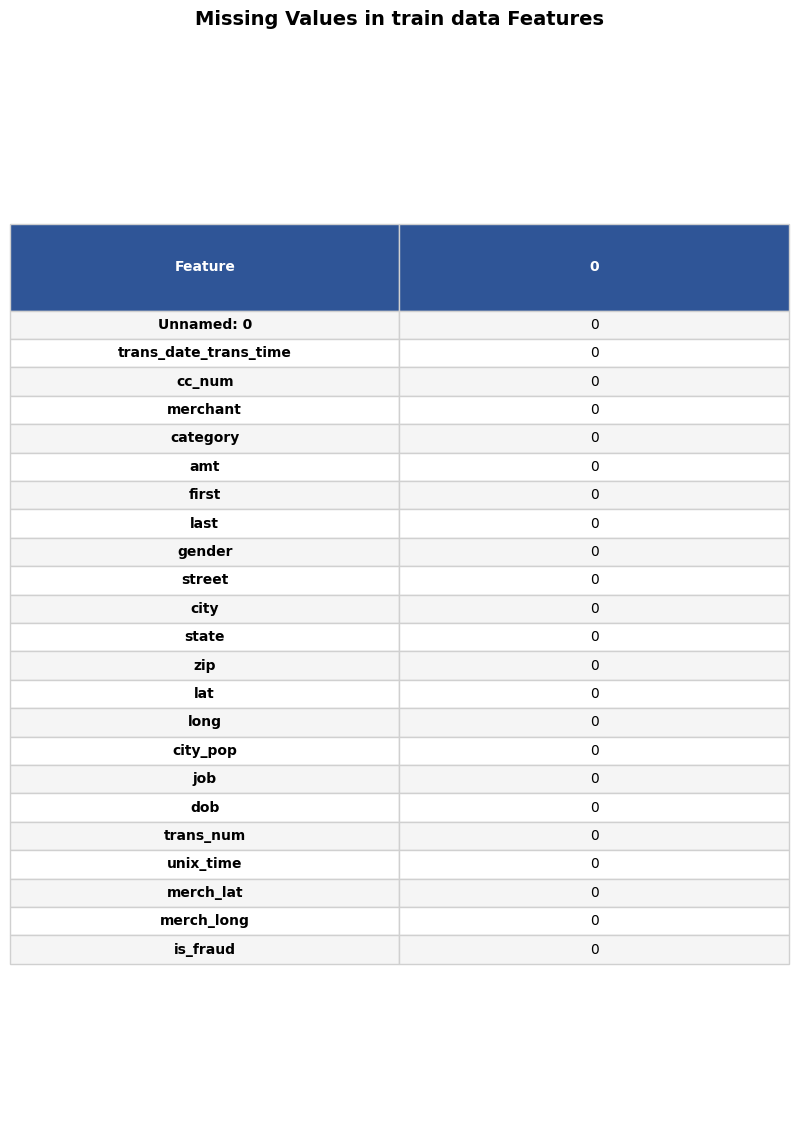

(<Figure size 800x1155 with 1 Axes>,
 <Axes: title={'center': 'Missing Values in train data Features'}>)

In [7]:
plot_utils.plot_table(
    train_data.isnull().sum().sort_values(ascending = False).reset_index().rename(
        columns ={
            "index": "Feature",
            "target": "Missing Values"
        }
    ),
    title = "Missing Values in train data Features",
    precision = 3,
    row_colors=("#F5F5F5", "white")
)

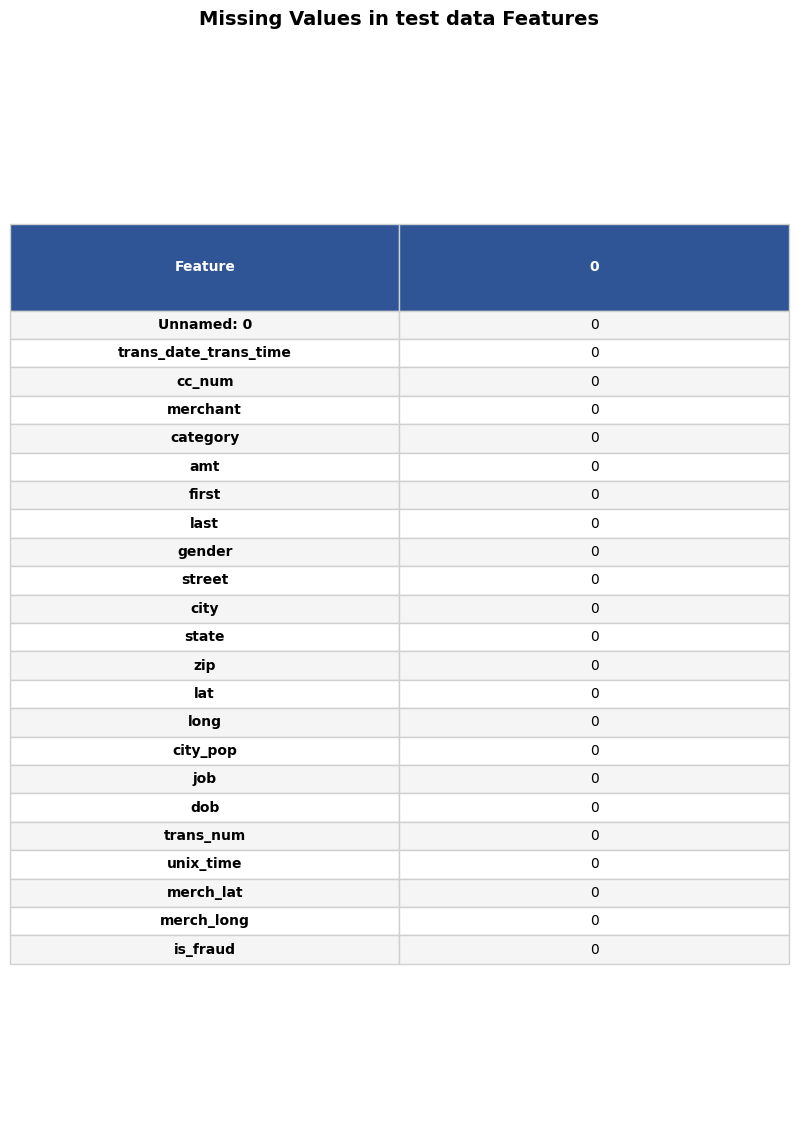

(<Figure size 800x1155 with 1 Axes>,
 <Axes: title={'center': 'Missing Values in test data Features'}>)

In [8]:
plot_utils.plot_table(
    test_data.isnull().sum().sort_values(ascending = False).reset_index().rename(
        columns ={
            "index": "Feature",
            "target": "Missing Values"
        }
    ),
    title = "Missing Values in test data Features",
    precision = 3,
    row_colors=("#F5F5F5", "white")
)

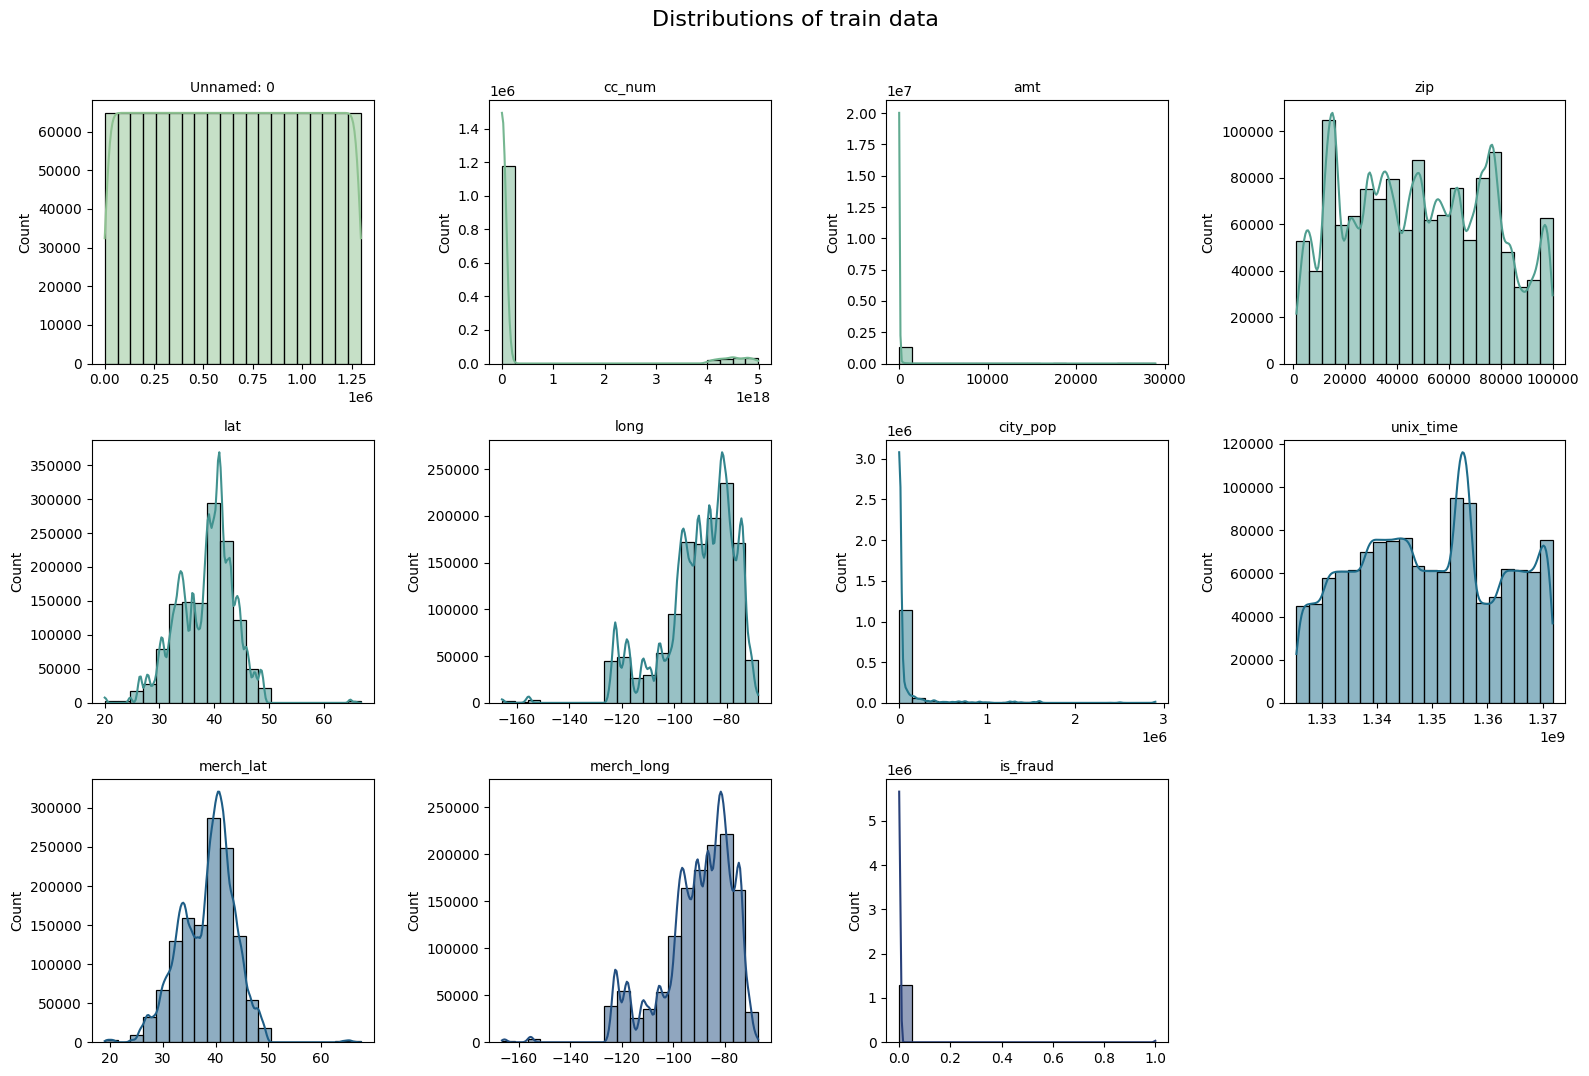

In [9]:
train_numeric_df = train_data.select_dtypes(include=["int64", "float64"])
plot_utils.distribution_plot(train_numeric_df, 'train')

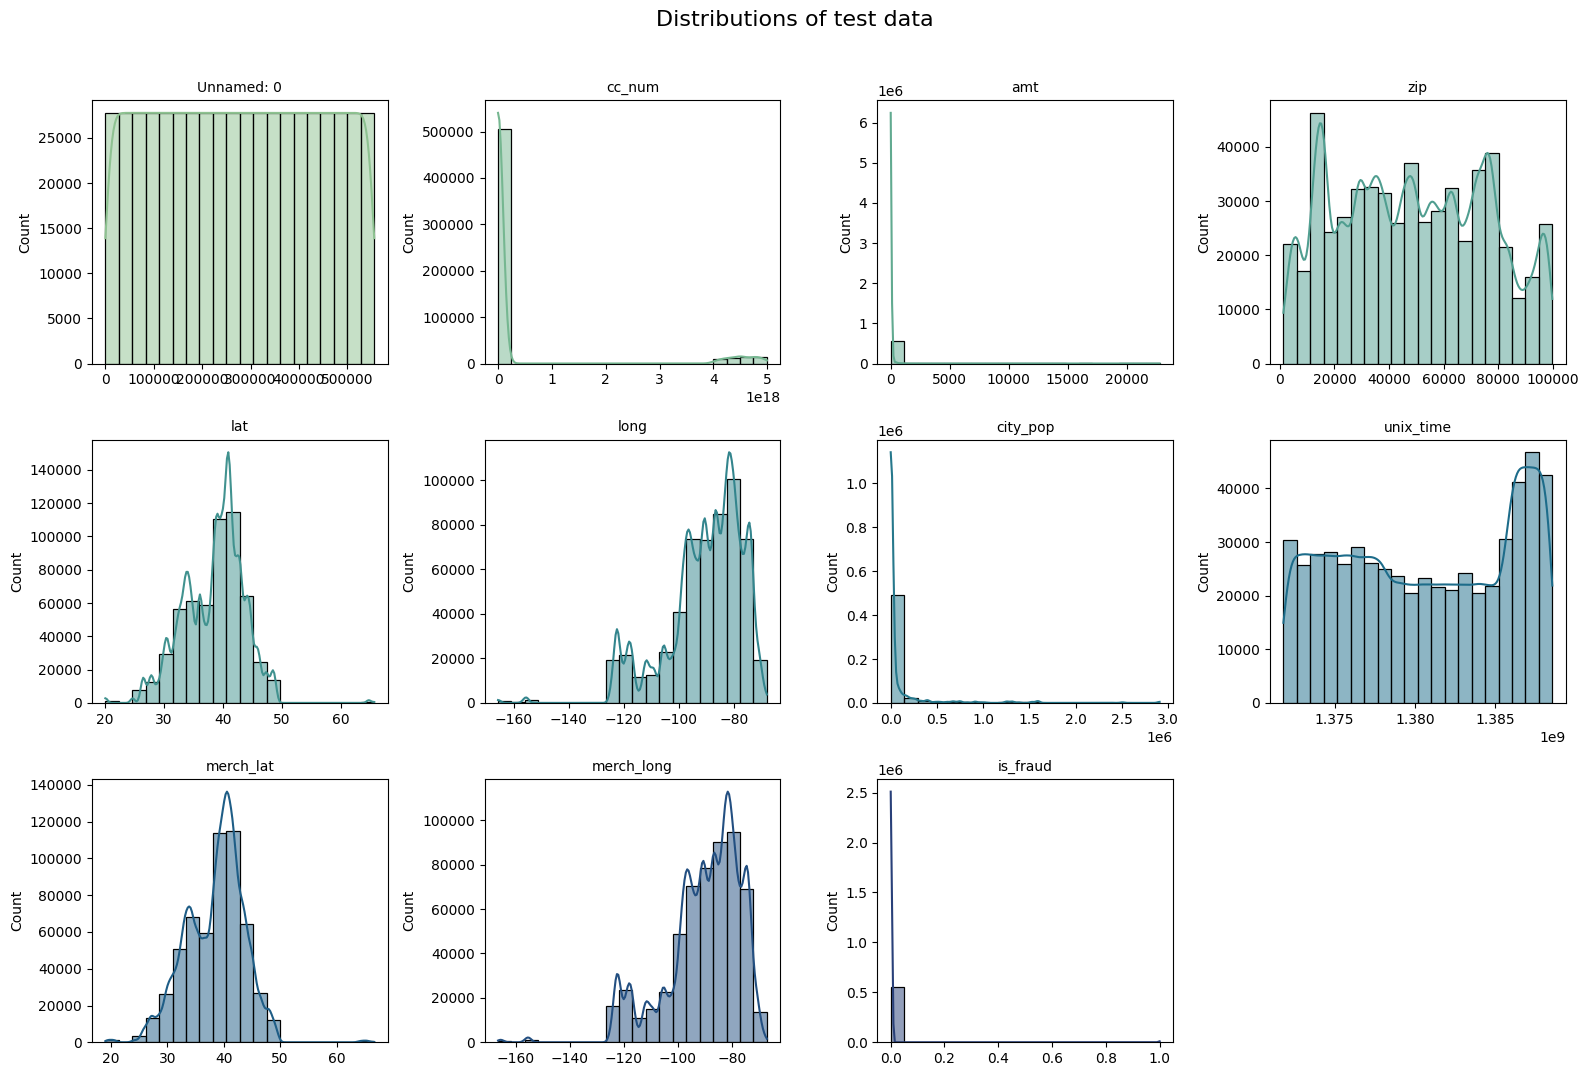

In [10]:
test_numeric_df = test_data.select_dtypes(include=["int64", "float64"])
plot_utils.distribution_plot(test_numeric_df, 'test')

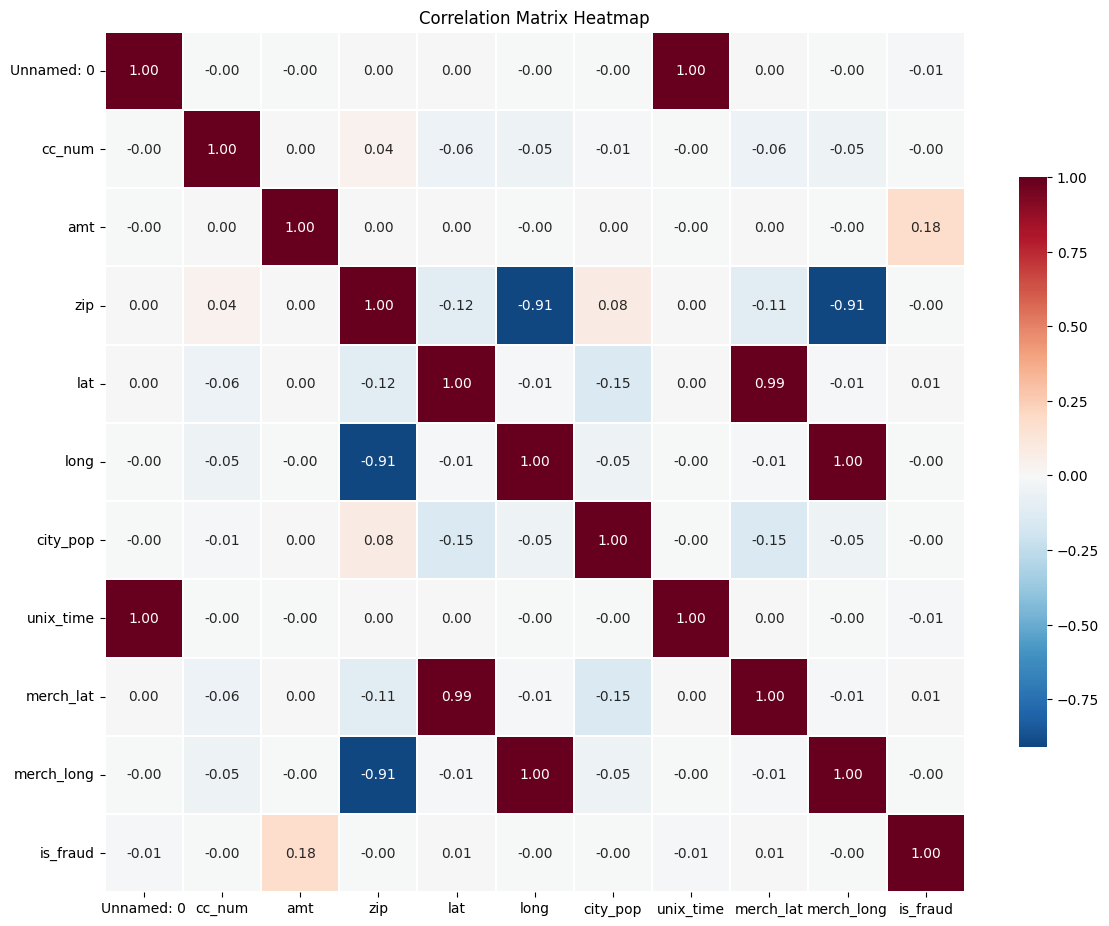

In [11]:
corr_matrix = test_data[train_numeric_df.columns].corr()
plot_utils.corr_plot(corr_matrix)

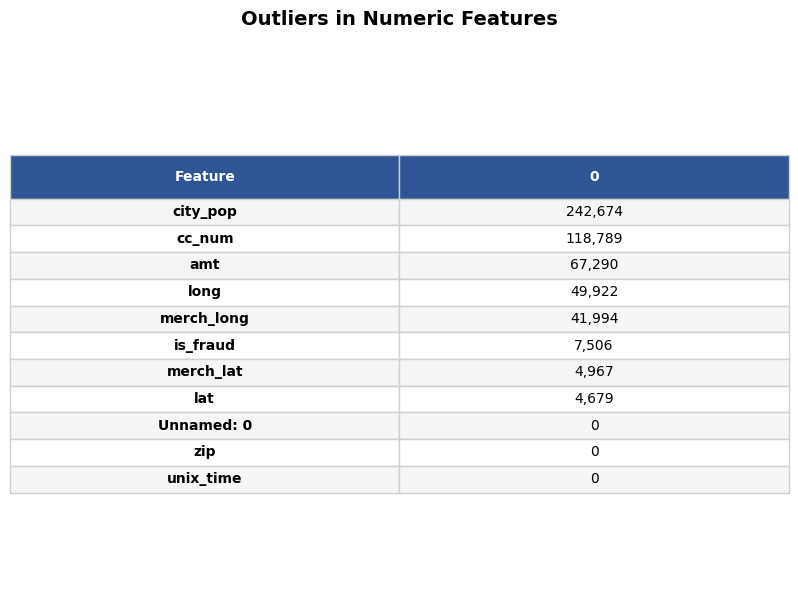

(<Figure size 800x615 with 1 Axes>,
 <Axes: title={'center': 'Outliers in Numeric Features'}>)

In [12]:
numeric_df = train_data.select_dtypes(include=["int64", "float64"])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))

plot_utils.plot_table(
    outliers.sum().sort_values(ascending = False).reset_index().rename(
        columns={
            "index": "Feature",
            "target": "Outliers"
        }
    ),
    title="Outliers in Numeric Features",
    precision=3
)

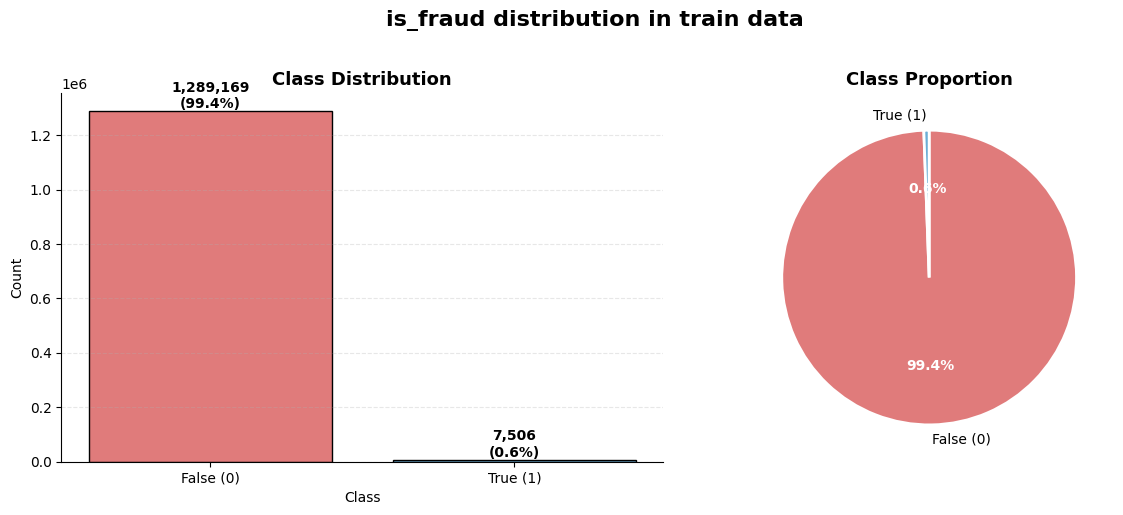

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': 'Class Distribution'}, xlabel='Class', ylabel='Count'>,
        <Axes: title={'center': 'Class Proportion'}>], dtype=object))

In [13]:
plot_utils.plot_target_distribution(train_data, 'is_fraud', ["False (0)", "True (1)"], ["#e07b7b", "#6baed6"], title = 'is_fraud distribution in train data')

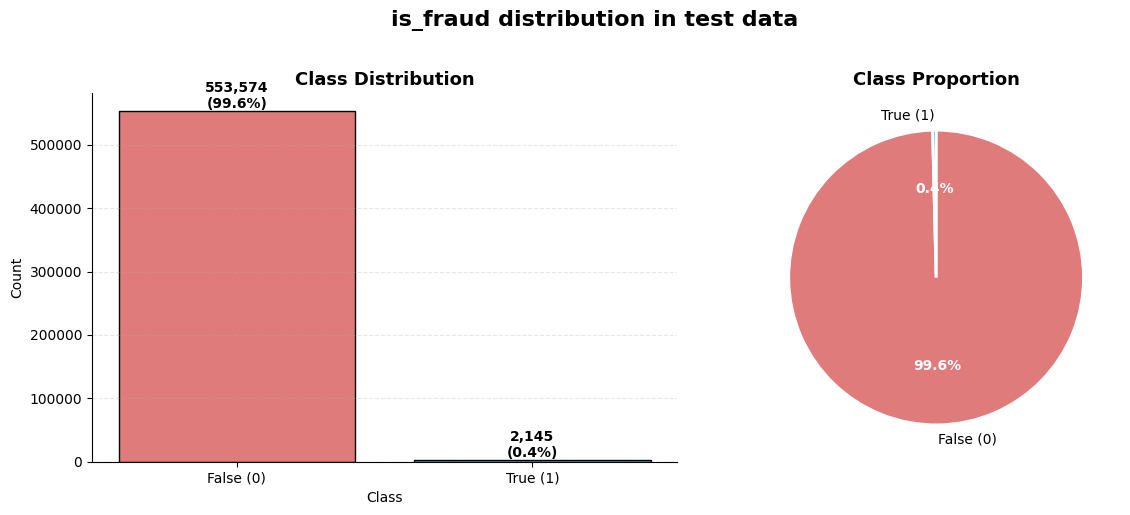

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': 'Class Distribution'}, xlabel='Class', ylabel='Count'>,
        <Axes: title={'center': 'Class Proportion'}>], dtype=object))

In [14]:
plot_utils.plot_target_distribution(test_data, 'is_fraud', ["False (0)", "True (1)"], ["#e07b7b", "#6baed6"], title = 'is_fraud distribution in test data')

In [15]:
def haversine_distance(lat1, lon1, lat2, lon2):
    
    R = 6371.0 

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [16]:
def preprocessor(df):
    df = df.copy()

    df["trans_date_trans_time"] = pd.to_datetime(
        df["trans_date_trans_time"]
    )

    df["dob"] = pd.to_datetime(df["dob"])

    df["age"] = (
        (df["trans_date_trans_time"] - df["dob"])
        .dt.days // 365
    )

    df["hour"] = df["trans_date_trans_time"].dt.hour
    df["day"] = df["trans_date_trans_time"].dt.day
    df["month"] = df["trans_date_trans_time"].dt.month
    df["dayofweek"] = (
        df["trans_date_trans_time"]
        .dt.dayofweek
    )

    df["is_weekend"] = (
        df["dayofweek"] >= 5
    ).astype(int)

    df["log_amt"] = np.log1p(df["amt"])

    df["distance"] = haversine_distance(
        df["lat"],
        df["long"],
        df["merch_lat"],
        df["merch_long"]
    )

    drop_cols = [
        "index",
        "first",
        "last",
        "street",
        "trans_num",
        "trans_date_trans_time",
        "dob"
    ]

    existing_cols = [
        c for c in drop_cols
        if c in df.columns
    ]

    df.drop(
        columns=existing_cols,
        inplace=True
    )

    return df

In [17]:
X_train = train_data.drop(columns=["is_fraud"], inplace = False)
Y_train = train_data["is_fraud"]

In [18]:
X_test = test_data.drop(columns=["is_fraud"], inplace = False)
Y_test = test_data["is_fraud"]

In [19]:
X_train = preprocessor(X_train)
X_test = preprocessor(X_test)

In [20]:
gender_map = {
    "M": 0,
    "F": 1
}

X_train["gender"] = X_train["gender"].map(gender_map)
X_test["gender"] = X_test["gender"].map(gender_map)

In [21]:
for col in ["merchant", "job"]:

    freq = X_train[col].value_counts()

    X_train[col] = X_train[col].map(freq)

    X_test[col] = (
        X_test[col]
        .map(freq)
        .fillna(0)
    )

for col in ["city", "state"]:
    freq = X_train[col].value_counts()

    X_train[col] = X_train[col].map(freq)
    X_test[col] = X_test[col].map(freq).fillna(0)

In [22]:
le = LabelEncoder()

X_train["category"] = le.fit_transform(
    X_train["category"]
)

mapping = {
    k: v
    for k, v in zip(
        le.classes_,
        le.transform(le.classes_)
    )
}

X_test["category"] = (
    X_test["category"]
    .map(mapping)
    .fillna(-1)
    .astype(int)
)

In [23]:
smote = SMOTE(
    sampling_strategy= 0.7, 
    random_state = 42)

X_res, Y_res = smote.fit_resample(
    X_train, 
    Y_train)

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_res
)

X_test_scaled = scaler.transform(
    X_test
)

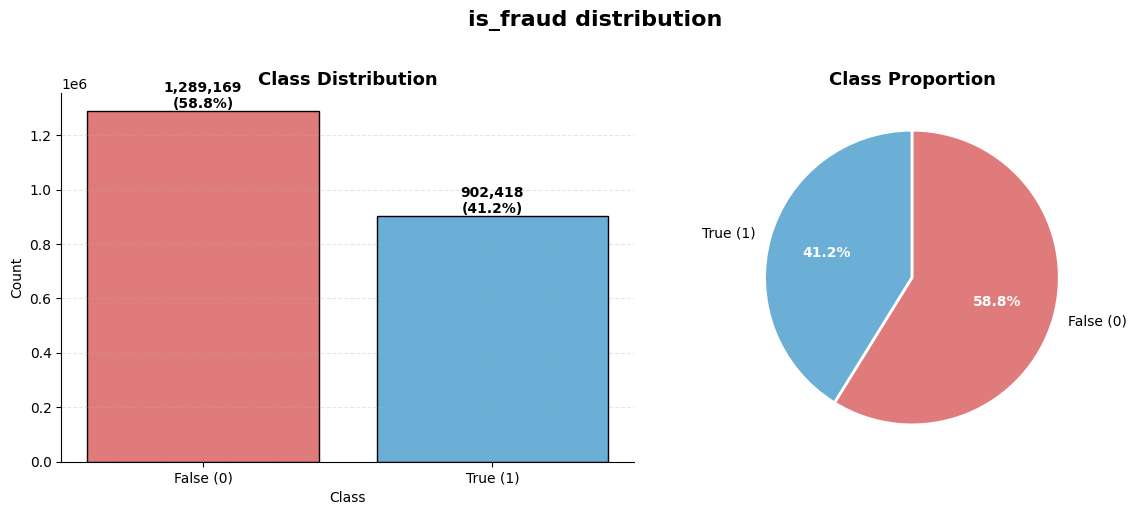

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': 'Class Distribution'}, xlabel='Class', ylabel='Count'>,
        <Axes: title={'center': 'Class Proportion'}>], dtype=object))

In [25]:
y_df = pd.DataFrame(Y_res)
plot_utils.plot_target_distribution(y_df, 'is_fraud' ,["False (0)", "True (1)"], ["#e07b7b", "#6baed6"], title = 'is_fraud distribution')

In [26]:
models_dict = {
    "Random Forest Classifier" : RandomForestClassifier(
                n_estimators = 600,
                max_depth = None,
                min_samples_split = 5,
                min_samples_leaf = 2,
                max_features = "sqrt",
                class_weight = "balanced_subsample",
                n_jobs = -1,
                random_state = 42
                ),
    
    "XGB Classifier" :   XGBClassifier(
                n_estimators = 1200,
                learning_rate = 0.03,
                max_depth = 5,
                subsample = 0.7,
                colsample_bytree = 0.7,
                min_child_weight = 3,
                gamma = 0.1,
                scale_pos_weight = 99,
                reg_alpha = 0.2,
                reg_lambda = 2,
                tree_method = "hist",
                eval_metric = "auc",
                random_state = 42
                ),

    "Logistic Regression" : LogisticRegression(
                max_iter = 3000,
                class_weight = "balanced",
                solver = "saga",
                C = 0.5,
                penalty = "l2"
                ),

    "LGBM Classifier" : LGBMClassifier(
                n_estimators = 1500,
                learning_rate = 0.03,
                num_leaves = 64,
                max_depth = -1,
                subsample = 0.7,
                colsample_bytree = 0.7,
                min_child_samples = 20,
                reg_alpha = 0.1,
                reg_lambda = 0.2,
                class_weight = "balanced",
                random_state = 42
                ),

    "CatBoostClassifier" : CatBoostClassifier(
                iterations = 1500,
                learning_rate = 0.03,
                depth = 8,
                l2_leaf_reg = 5,
                auto_class_weights = "Balanced",
                bagging_temperature = 0.5,
                random_seed = 42,
                verbose = 0
                )
    
}

In [27]:
def train_single_model(model_name, model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    
    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC Score": roc_auc_score(y_test, y_pred),
        "confusion_matrix" : confusion_matrix(y_test, y_pred),
        "y_pred": y_pred,
    }

    return result

In [29]:
def run_models(X_train, y_train, X_test, y_test, models):
    
    all_results = []
    test_predictions_dict = {}

    for model_name, model in models.items():
        print(f"\nTraining {model_name} ...")

        result = train_single_model(
            model_name = model_name,
            model = model,
            X_train = X_train,
            y_train = y_train,
            X_test = X_test,
            y_test = y_test
        )

        all_results.append(result)

        print("==========================================================")
        print()
        print(f"Accuracy : {result["Accuracy"]}")
        print(f"Precision : {result["Precision"]}")
        print(f"Recall : {result["Recall"]}")
        print(f"F1 Score : {result["F1 Score"]}")
        print(f"ROC AUC Score : {result["ROC AUC Score"]}")
        print()
        print("==========================================================")

        plot_utils.confusion_plot(result["confusion_matrix"], model_name)
        plot_utils.plot_roc_curve(Y_test, result["y_pred"], model_name, show_thresholds = True)

    all_results_df = pd.DataFrame(all_results)
    
    all_results_df = all_results_df.drop(columns=['confusion_matrix'])
    
    return all_results_df


Training Random Forest Classifier ...

Accuracy : 0.9984470568758671
Precision : 0.8713789107763615
Recall : 0.7011655011655011
F1 Score : 0.7770601911650736
ROC AUC Score : 0.8503822353851437



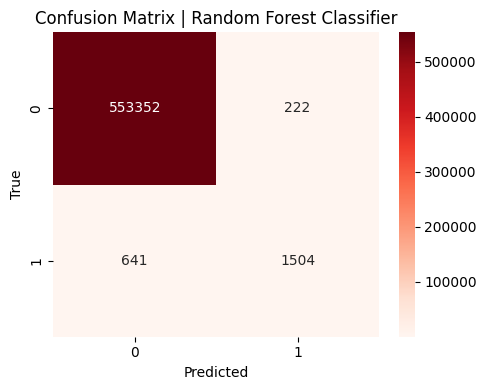

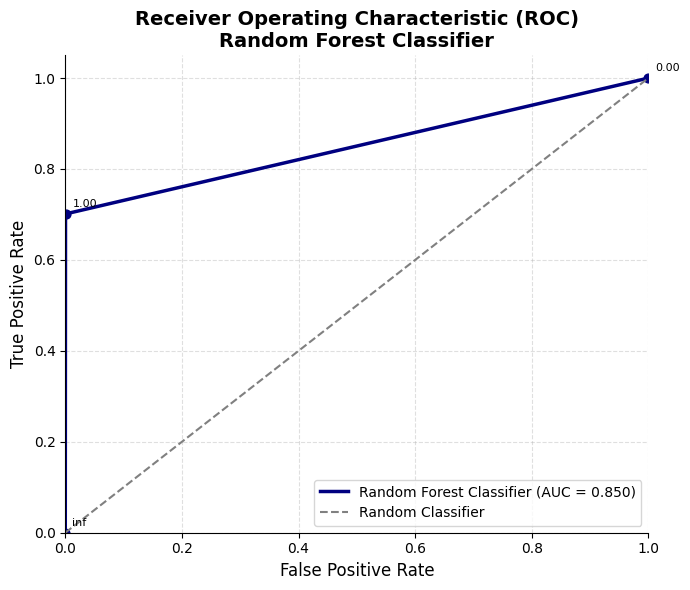


Training XGB Classifier ...

Accuracy : 0.9825145442210902
Precision : 0.17401412088858276
Recall : 0.9421911421911422
F1 Score : 0.2937713496620394
ROC AUC Score : 0.9624309661827681



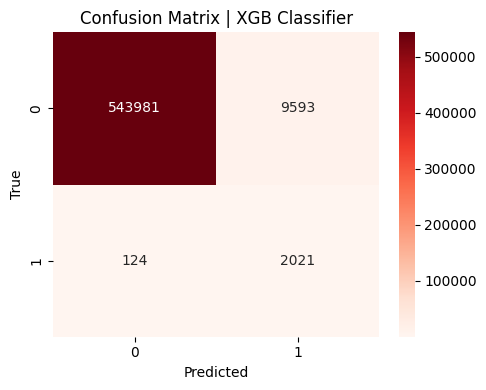

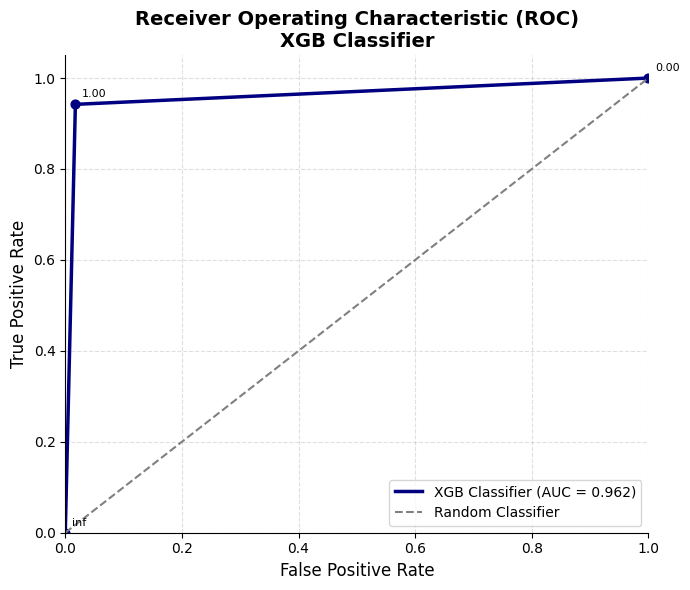


Training Logistic Regression ...

Accuracy : 0.9929028879703591
Precision : 0.26544980443285526
Recall : 0.4745920745920746
F1 Score : 0.34046822742474914
ROC AUC Score : 0.7347516620182967



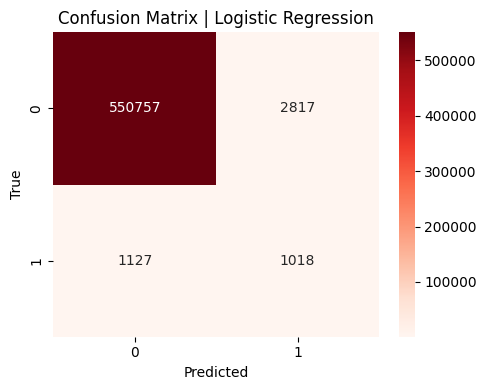

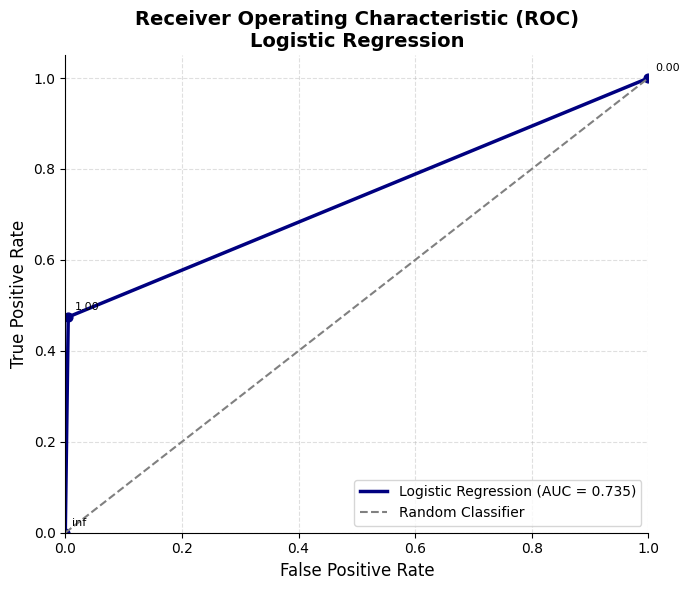


Training LGBM Classifier ...
[LightGBM] [Info] Number of positive: 902418, number of negative: 1289169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.506675 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4251
[LightGBM] [Info] Number of data points in the train set: 2191587, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Accuracy : 0.9986449986413997
Precision : 0.9767123287671233
Recall : 0.6648018648018648
F1 Score : 0.791123439667129
ROC AUC Score : 0.8323702228661637



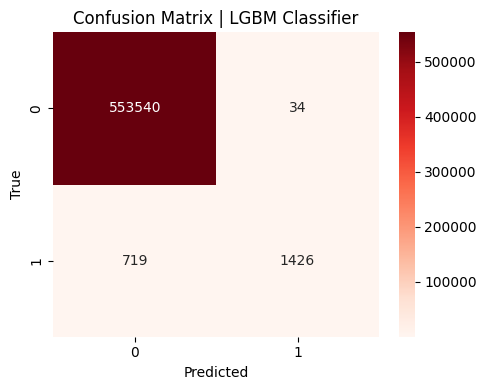

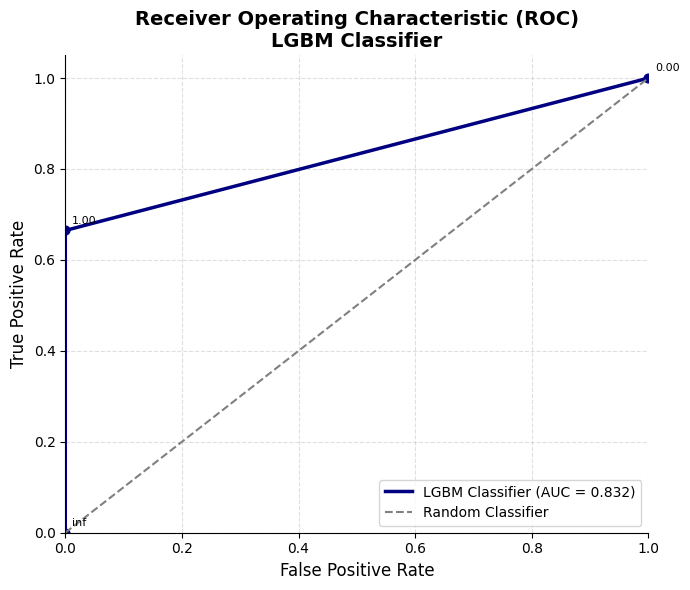


Training CatBoostClassifier ...

Accuracy : 0.9980637696389723
Precision : 0.7152637937978252
Recall : 0.827972027972028
F1 Score : 0.7675021607605877
ROC AUC Score : 0.913347436307149



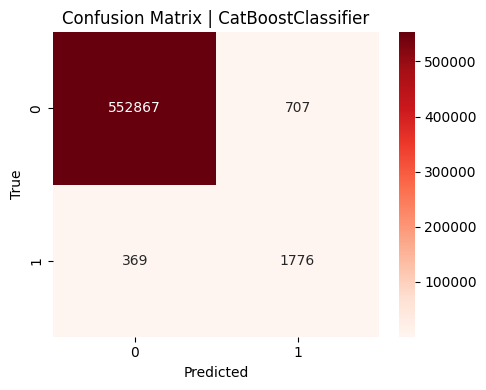

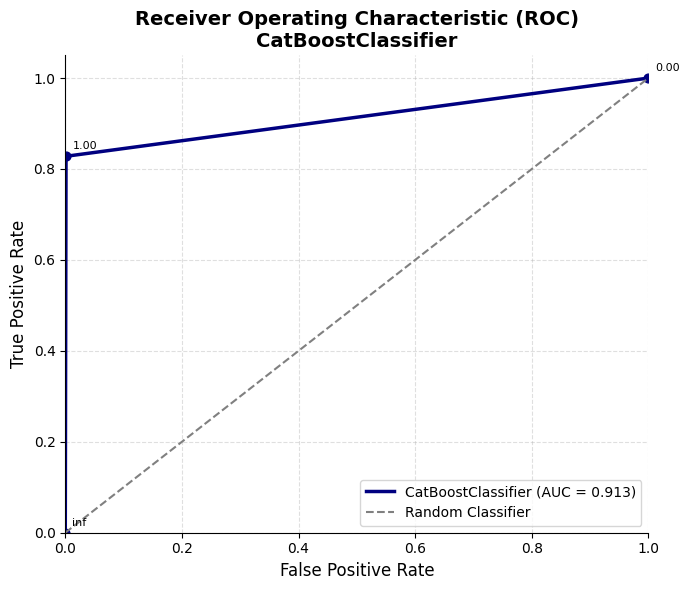

In [30]:
all_models_result = run_models(X_train = X_train_scaled, y_train = Y_res, X_test = X_test_scaled, y_test = Y_test, models = models_dict)

In [33]:
X_train = torch.from_numpy(X_train_scaled).float()
y_train = torch.from_numpy(Y_res.to_numpy()).float().view(-1, 1)

X_test = torch.from_numpy(X_test_scaled).float()
y_test = torch.from_numpy(Y_test.to_numpy()).float().view(-1, 1)

In [34]:
train_set = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_set, batch_size = 256, shuffle = True)

test_set = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_set, batch_size = 256, shuffle = False)

In [46]:
num_samples, num_features = X_train_scaled.shape

num_classes = 2

model = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),

    nn.Dropout(0.3),

    nn.Linear(128, 64),
    nn.ReLU(),

    nn.Dropout(0.3),

    nn.Linear(64, 32),
    nn.ReLU(),

    nn.Linear(32, 1)
)
model

Sequential(
  (0): Linear(in_features=24, out_features=128, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=64, out_features=32, bias=True)
  (7): ReLU()
  (8): Linear(in_features=32, out_features=1, bias=True)
)

In [47]:
loss_fn = nn.BCEWithLogitsLoss().to(device)
loss_fn

BCEWithLogitsLoss()

In [48]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 1e-3,
    weight_decay = 1e-5
)

In [51]:
n_epochs = 10

for epoch in range(n_epochs):
    model.train()

    total_loss_train = 0
    total_correct_train = 0
    all_y_true = []
    all_y_pred = []
    all_y_prob = []

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.float().view(-1, 1).to(device)

        optimizer.zero_grad()

        logits = model(x_batch)
        loss = loss_fn(logits, y_batch)
        loss.backward()
        optimizer.step()

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        total_loss_train += loss.item() * x_batch.size(0)
        total_correct_train += (preds == y_batch).sum().item()

        all_y_true.extend(y_batch.detach().cpu().numpy().ravel())
        all_y_pred.extend(preds.detach().cpu().numpy().ravel())
        all_y_prob.extend(probs.detach().cpu().numpy().ravel())

    mean_loss_train = total_loss_train / len(train_loader.dataset)
    mean_acc_train = total_correct_train / len(train_loader.dataset)

    precision = precision_score(all_y_true, all_y_pred, zero_division=0)
    recall = recall_score(all_y_true, all_y_pred, zero_division=0)
    f1 = f1_score(all_y_true, all_y_pred, zero_division=0)
    roc_auc = roc_auc_score(all_y_true, all_y_prob)

    loss_train_hist.append(mean_loss_train)
    acc_train_hist.append(mean_acc_train)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss = {mean_loss_train:.4f} | "
        f"Acc = {mean_acc_train:.4f} | "
        f"Precision = {precision:.4f} | "
        f"Recall = {recall:.4f} | "
        f"F1 = {f1:.4f} | "
        f"AUC = {roc_auc:.4f}"
    )

Epoch 01 | Loss = 0.0487 | Acc = 0.9824 | Precision = 0.9802 | Recall = 0.9771 | F1 = 0.9786 | AUC = 0.9983
Epoch 02 | Loss = 0.0465 | Acc = 0.9833 | Precision = 0.9807 | Recall = 0.9786 | F1 = 0.9797 | AUC = 0.9985
Epoch 03 | Loss = 0.0447 | Acc = 0.9840 | Precision = 0.9816 | Recall = 0.9796 | F1 = 0.9806 | AUC = 0.9986
Epoch 04 | Loss = 0.0437 | Acc = 0.9844 | Precision = 0.9817 | Recall = 0.9802 | F1 = 0.9810 | AUC = 0.9986
Epoch 05 | Loss = 0.0425 | Acc = 0.9848 | Precision = 0.9822 | Recall = 0.9809 | F1 = 0.9815 | AUC = 0.9987
Epoch 06 | Loss = 0.0413 | Acc = 0.9853 | Precision = 0.9826 | Recall = 0.9816 | F1 = 0.9821 | AUC = 0.9988
Epoch 07 | Loss = 0.0405 | Acc = 0.9855 | Precision = 0.9828 | Recall = 0.9820 | F1 = 0.9824 | AUC = 0.9988
Epoch 08 | Loss = 0.0397 | Acc = 0.9859 | Precision = 0.9831 | Recall = 0.9826 | F1 = 0.9829 | AUC = 0.9989
Epoch 09 | Loss = 0.0388 | Acc = 0.9861 | Precision = 0.9834 | Recall = 0.9829 | F1 = 0.9831 | AUC = 0.9989
Epoch 10 | Loss = 0.0385 | A

In [53]:
all_preds = []
all_targets = []

model.eval() 
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device).view(-1, 1).float()
        y_hat = model(x_batch)
        
        threshold = 0.5
        predicted_classes = (y_hat >= threshold).int() 
        
        all_preds.extend(predicted_classes.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())

In [54]:
mlp_accuracy  = accuracy_score(all_targets, all_preds)   
mlp_precision = precision_score(all_targets, all_preds, average = 'macro',  zero_division = 0)
mlp_recall = recall_score(all_targets, all_preds, average = 'macro',  zero_division = 0)
mlp_f1_score = f1_score(all_targets, all_preds, average = 'macro')
mlp_roc_auc = roc_auc_score(all_targets, all_preds)
mlp_conf_matrix = confusion_matrix(all_targets, all_preds)

In [55]:
print(f"Accuracy: {mlp_accuracy:.4f}")
print(f"Precision: {mlp_precision:.4f}")
print(f"Recall: {mlp_recall:.4f}")
print(f"F1 Score: {mlp_f1_score:.4f}")
print(f"ROC AUC Score: {mlp_roc_auc:.4f}")

Accuracy: 0.9967
Precision: 0.7753
Recall: 0.8544
F1 Score: 0.8098
ROC AUC Score: 0.8544


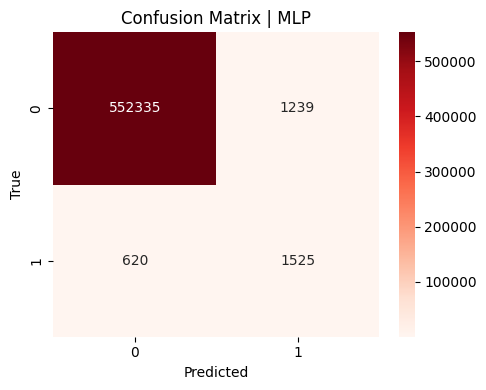

In [59]:
plot_utils.confusion_plot(mlp_conf_matrix, 'MLP')

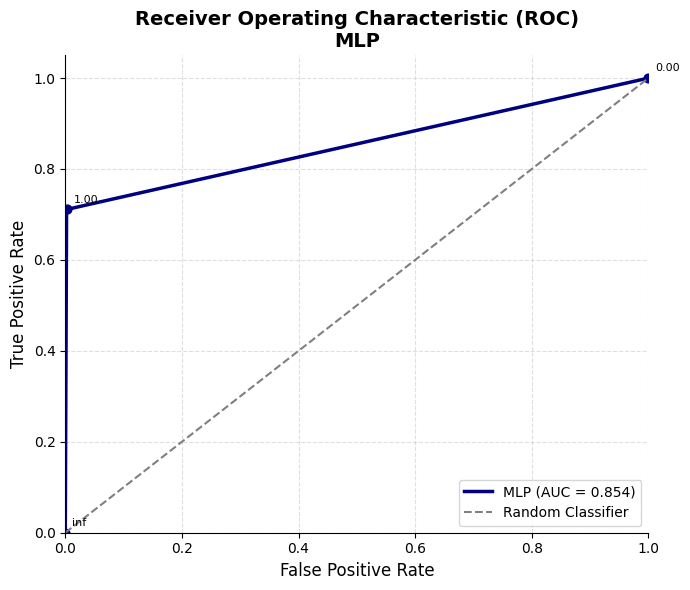

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'Receiver Operating Characteristic (ROC)\nMLP'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>,
 np.float64(0.8543587639020228))

In [62]:
plot_utils.plot_roc_curve(all_targets, all_preds, 'MLP', show_thresholds = True)

In [90]:
mlp_result = {
    "Model": "MLP",
    "Accuracy": mlp_accuracy,
    "Precision": mlp_precision,
    "Recall": mlp_recall,
    "F1 Score": mlp_f1_score,
    "ROC AUC Score": mlp_roc_auc,
    "y_pred": all_preds
}

mlp_df = pd.DataFrame(mlp_result)
result_df = pd.concat([all_models_result, mlp_df], ignore_index = True)
result_df = result_df.drop_duplicates(subset=['Model'])

In [86]:
result_show = result_df.drop(columns = ["y_pred"]).sort_values(by = "F1 Score", ascending = False, ignore_index = True)
result_show

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC Score
0,MLP,0.996655,0.775308,0.854359,0.809814,0.854359
1,LGBM Classifier,0.998645,0.976712,0.664802,0.791123,0.832370
2,Random Forest Classifier,0.998447,0.871379,0.701166,0.777060,0.850382
3,CatBoostClassifier,0.998064,0.715264,0.827972,0.767502,0.913347
4,Logistic Regression,0.992903,0.265450,0.474592,0.340468,0.734752
5,XGB Classifier,0.982515,0.174014,0.942191,0.293771,0.962431


In [80]:
best_model = result_df.sort_values(by = "F1 Score", ascending = False).iloc[0]["Model"] 
print(f"best model by F1 score : {best_model}")

best model by F1 score : MLP


In [89]:
def get_preds(model_name):
    row = result_df[result_df["Model"] == model_name]
    if not row.empty:
        return row.iloc[0]["y_pred"]
    else:
        return None

pred_map = {
    "Random Forest Classifier": get_preds("Random Forest Classifier"),
    "XGB Classifier": get_preds("XGB Classifier"),
    "Logistic Regression": get_preds("Logistic Regression"),
    "LGBM Classifier": get_preds("LGBM Classifier"),
    "CatBoostClassifier": get_preds("CatBoostClassifier"),
    "MLP": all_preds
}

best_preds = pred_map[best_model]

submission = pd.DataFrame({
    "index": test_data.index + 1,
    "is_fraud": best_preds
})

submission.to_csv("submission.csv", index = False)